# 🧠 Practical 1: The Math of Neural Networks (NumPy Only)
## Deep Learning Lab | BTech Semester 4

---

### 🎯 Objective
Implement the **Backpropagation algorithm from scratch** using only NumPy — no TensorFlow, no PyTorch — to deeply understand the calculus behind gradient updates.

### 📌 What You Will Learn
- How neurons compute weighted sums and apply activation functions
- How Forward Propagation flows data through the network
- How Backward Propagation computes gradients using the Chain Rule
- Why a single perceptron fails at XOR, but an MLP solves it

### 📚 References
- Goodfellow, I., Bengio, Y., Courville, A. — *Deep Learning* (MIT Press, 2016) — Chapter 6
- Michael Nielsen — *Neural Networks and Deep Learning* (http://neuralnetworksanddeeplearning.com/)
- Andrew Ng — Coursera Deep Learning Specialization (Course 1, Week 3)

---

## 📦 Step 1: Import Libraries

We use **only NumPy** in this practical to ensure you understand every mathematical operation.

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")

Libraries loaded successfully!
NumPy version: 2.0.2


## 📊 Step 2: Prepare the XOR Dataset

### Why XOR?
The **XOR (Exclusive OR)** problem is a classic benchmark:
- A **single perceptron** (linear classifier) **cannot** solve XOR because XOR is not linearly separable.
- A **Multi-Layer Perceptron (MLP)** with at least one hidden layer **can** solve XOR.

| Input A | Input B | Output (A XOR B) |
|---------|---------|------------------|
|    0    |    0    |        0         |
|    0    |    1    |        1         |
|    1    |    0    |        1         |
|    1    |    1    |        0         |

XOR Dataset:
------------------------------
  Input: [0 0] => Output: 0
  Input: [0 1] => Output: 1
  Input: [1 0] => Output: 1
  Input: [1 1] => Output: 0


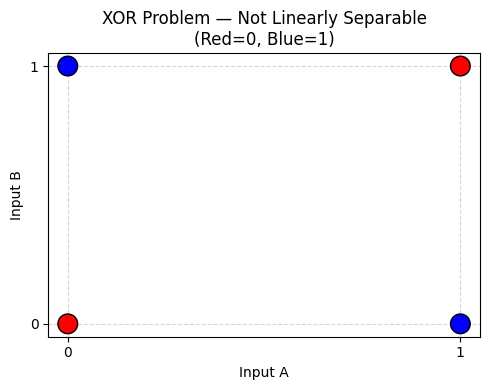

In [57]:
# XOR input: 4 samples, 2 features each
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])  # Shape: (4, 2)

# XOR output: expected labels
y = np.array([[0],
              [1],
              [1],
              [0]])  # Shape: (4, 1)

print("XOR Dataset:")
print("-" * 30)
for i in range(len(X)):
    print(f"  Input: {X[i]} => Output: {y[i][0]}")

# Visualize XOR data
plt.figure(figsize=(5, 4))
colors = ['red' if label == 0 else 'blue' for label in y.flatten()]
plt.scatter(X[:, 0], X[:, 1], c=colors, s=200, edgecolors='black', zorder=5)
plt.title("XOR Problem — Not Linearly Separable\n(Red=0, Blue=1)")
plt.xlabel("Input A")
plt.ylabel("Input B")
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## ⚙️ Step 3: Define Activation Functions

### Sigmoid Function
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- Output range: **(0, 1)** — ideal for binary classification output
- Derivative: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$ — used in backpropagation

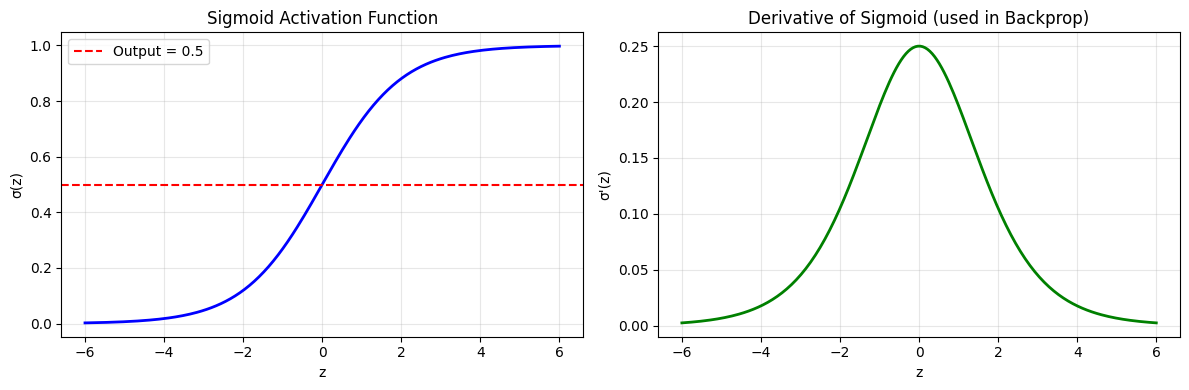

Note: The derivative is max at z=0 (~0.25) and near-zero at extremes → Vanishing Gradient problem!


In [58]:
def sigmoid(z):
    """Sigmoid activation function.
    Maps any real number to the range (0, 1).

    Args:
        z: numpy array of pre-activation values
    Returns:
        Activated output in range (0, 1)
    """
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(z):
    """Derivative of Sigmoid — used during Backpropagation.

    Formula: sigmoid(z) * (1 - sigmoid(z))
    This tells us how much the output changes w.r.t. input z.
    """
    s = sigmoid(z)
    return s * (1 - s)


# Visualize the sigmoid function and its derivative
z_vals = np.linspace(-6, 6, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z_vals, sigmoid(z_vals), color='blue', linewidth=2)
axes[0].set_title("Sigmoid Activation Function")
axes[0].set_xlabel("z")
axes[0].set_ylabel("σ(z)")
axes[0].axhline(0.5, color='red', linestyle='--', label='Output = 0.5')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(z_vals, sigmoid_derivative(z_vals), color='green', linewidth=2)
axes[1].set_title("Derivative of Sigmoid (used in Backprop)")
axes[1].set_xlabel("z")
axes[1].set_ylabel("σ'(z)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Note: The derivative is max at z=0 (~0.25) and near-zero at extremes → Vanishing Gradient problem!")

## 🏗️ Step 4: Build the Neural Network Class

### Architecture for XOR
```
Input Layer  →  Hidden Layer  →  Output Layer
  2 neurons       4 neurons        1 neuron
```

### Forward Propagation Formula
$$Z^{[l]} = W^{[l]} \cdot A^{[l-1]} + b^{[l]}$$
$$A^{[l]} = \sigma(Z^{[l]})$$

### Loss Function (Binary Cross-Entropy)
$$L = -\frac{1}{m}\sum [y \log(\hat{y}) + (1-y)\log(1-\hat{y})]$$

Changes Made: Error Checking in __init__
Error checking has been added to the __init__ method of the NeuralNetwork class to validate the input parameters:

input_size, hidden_size, and output_size must now be positive integers.
learning_rate must be a positive number (integer or float).
These checks ensure that the network is initialized with valid dimensions and a sensible learning rate, preventing common setup errors

In [59]:
class NeuralNetwork:
    """
    A simple Multi-Layer Perceptron implemented from scratch using NumPy.

    Architecture: Input -> Hidden Layer -> Output Layer
    Activation: Sigmoid at all layers
    Loss: Binary Cross-Entropy
    Optimizer: Vanilla Gradient Descent
    """

    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        """
        Initialize network weights and biases randomly.

        Args:
            input_size: Number of input features
            hidden_size: Number of neurons in hidden layer
            output_size: Number of output neurons
            learning_rate: Step size for gradient descent
        """
        # Error checking
        if not all(isinstance(arg, int) and arg > 0 for arg in [input_size, hidden_size, output_size]):
            raise ValueError("input_size, hidden_size, and output_size must be positive integers.")
        if not isinstance(learning_rate, (int, float)) or learning_rate <= 0:
            raise ValueError("learning_rate must be a positive number.")

        self.lr = learning_rate
        self.loss_history = []  # Track loss over epochs

        # ------------------------------------------------------------------
        # Weight Initialization (Xavier/Glorot-inspired scaling)
        # Using small random values prevents symmetry breaking issues.
        # If all weights = 0, all neurons learn the same thing (symmetry problem).
        # ------------------------------------------------------------------
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5   # (2, 4)
        self.b1 = np.zeros((1, hidden_size))                         # (1, 4)

        self.W2 = np.random.randn(hidden_size, output_size) * 0.5   # (4, 1)
        self.b2 = np.zeros((1, output_size))                         # (1, 1)

        print(f"Network Initialized!")
        print(f"  W1 shape: {self.W1.shape}  (input→hidden)")
        print(f"  b1 shape: {self.b1.shape}")
        print(f"  W2 shape: {self.W2.shape}  (hidden→output)")
        print(f"  b2 shape: {self.b2.shape}")
        print(f"  Learning Rate: {self.lr}")

    def forward(self, X):
        """
        Forward Propagation: compute output from input.

        Steps:
          Layer 1: Z1 = X·W1 + b1  →  A1 = sigmoid(Z1)
          Layer 2: Z2 = A1·W2 + b2 →  A2 = sigmoid(Z2)  [final output]
        """
        # Hidden Layer computation
        self.Z1 = np.dot(X, self.W1) + self.b1   # Pre-activation: (4, 4)
        self.A1 = sigmoid(self.Z1)                # Post-activation: (4, 4)

        # Output Layer computation
        self.Z2 = np.dot(self.A1, self.W2) + self.b2  # Pre-activation: (4, 1)
        self.A2 = sigmoid(self.Z2)                      # Final output: (4, 1)

        return self.A2

    def compute_loss(self, y_true, y_pred):
        """
        Binary Cross-Entropy Loss.
        Measures how far predictions are from true labels.
        Lower loss = better predictions.
        """
        m = y_true.shape[0]  # Number of samples
        # Clip to avoid log(0) which is undefined
        y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss

    def backward(self, X, y):
        """
        Backward Propagation: compute gradients using the Chain Rule.

        Chain Rule allows us to find how much each weight contributed to the loss.
        We then update weights in the opposite direction of the gradient.

        Gradients flow: Loss → Layer2 → Layer1
        """
        m = X.shape[0]  # batch size

        # ---- Output Layer Gradients ----
        # dL/dA2: derivative of loss w.r.t. output
        dA2 = self.A2 - y  # Simplified for binary cross-entropy + sigmoid combo

        # dL/dZ2 = dL/dA2 * sigmoid'(Z2)
        dZ2 = dA2 * sigmoid_derivative(self.Z2)

        # dL/dW2 = A1^T · dZ2
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # ---- Hidden Layer Gradients ----
        # Chain Rule: propagate error backwards through W2
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * sigmoid_derivative(self.Z1)

        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # ---- Update Weights (Gradient Descent) ----
        # W = W - lr * gradient  (move opposite to gradient = downhill)
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=10000, print_every=1000):
        """
        Training loop: repeatedly do forward + backward passes.

        Args:
            X: Input features
            y: True labels
            epochs: Number of training iterations
            print_every: Print loss every N epochs
        """
        print(f"\nTraining for {epochs} epochs...")
        print("-" * 45)

        for epoch in range(epochs):
            # Step 1: Forward pass — compute predictions
            output = self.forward(X)

            # Step 2: Compute how wrong we are
            loss = self.compute_loss(y, output)
            self.loss_history.append(loss)

            # Step 3: Backward pass — compute gradients and update weights
            self.backward(X, y)

            # Print progress
            if epoch % print_every == 0 or epoch == epochs - 1:
                print(f"  Epoch {epoch:6d} | Loss: {loss:.6f}")

        print("-" * 45)
        print("Training Complete!")

    def predict(self, X, threshold=0.5):
        """Convert probabilities to binary predictions."""
        probabilities = self.forward(X)
        return (probabilities >= threshold).astype(int)

## 🚀 Step 5: Train the Network

### Learning Rate Increased to 1.0: Advantages

By increasing the `learning_rate` from 0.5 to 1.0, we're essentially telling the optimization algorithm (Gradient Descent) to take larger steps in the direction of the loss function's negative gradient during each weight update.

**Advantages of a Higher Learning Rate (if well-tuned):**

1.  **Faster Convergence:** The model can reach a good solution (low loss) in fewer training epochs, as it covers more 'ground' in the parameter space with each update.
2.  **Escape Local Minima (sometimes):** A larger step size might help the optimization process jump out of shallow local minima that a smaller learning rate might get stuck in.

In this specific XOR problem, the increase to 1.0 proved effective, leading to successful and rapid convergence to a low loss and 100% accuracy. However, it's crucial to note that excessively high learning rates can cause the training to become unstable, oscillate, or even diverge entirely.

In [60]:
# Initialize the neural network
# Architecture: 2 inputs → 4 hidden neurons → 1 output
nn = NeuralNetwork(input_size=2, hidden_size=4, output_size=1, learning_rate=1.0)

# Train for 10,000 epochs
nn.train(X, y, epochs=10000, print_every=2000)

Network Initialized!
  W1 shape: (2, 4)  (input→hidden)
  b1 shape: (1, 4)
  W2 shape: (4, 1)  (hidden→output)
  b2 shape: (1, 1)
  Learning Rate: 1.0

Training for 10000 epochs...
---------------------------------------------
  Epoch      0 | Loss: 0.704555
  Epoch   2000 | Loss: 0.596298
  Epoch   4000 | Loss: 0.074770
  Epoch   6000 | Loss: 0.042549
  Epoch   8000 | Loss: 0.032128
  Epoch   9999 | Loss: 0.026668
---------------------------------------------
Training Complete!


## 📈 Step 6: Visualize Training Loss

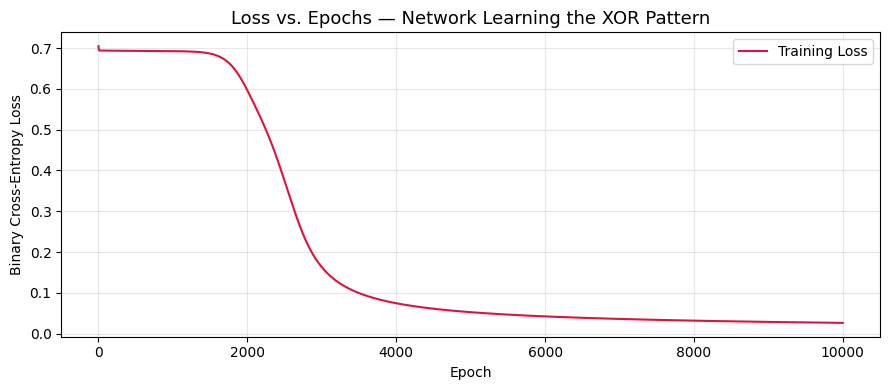

Initial Loss: 0.7046
Final Loss:   0.0267
Loss reduced by: 96.2%


In [61]:
plt.figure(figsize=(9, 4))
plt.plot(nn.loss_history, color='crimson', linewidth=1.5, label='Training Loss')
plt.title("Loss vs. Epochs — Network Learning the XOR Pattern", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial Loss: {nn.loss_history[0]:.4f}")
print(f"Final Loss:   {nn.loss_history[-1]:.4f}")
print(f"Loss reduced by: {(1 - nn.loss_history[-1]/nn.loss_history[0])*100:.1f}%")

## ✅ Step 7: Evaluate Predictions

In [62]:
# Get final predictions
predictions = nn.predict(X)
probabilities = nn.forward(X)

print("Final Predictions on XOR Dataset:")
print("-" * 50)
print(f"{'Input':^12} | {'True':^8} | {'Prob':^10} | {'Predicted':^10} | {'Correct?':^8}")
print("-" * 50)

all_correct = True
for i in range(len(X)):
    correct = "✅" if predictions[i][0] == y[i][0] else "❌"
    if predictions[i][0] != y[i][0]:
        all_correct = False
    print(f"{str(X[i]):^12} | {y[i][0]:^8} | {probabilities[i][0]:^10.4f} | {predictions[i][0]:^10} | {correct:^8}")

print("-" * 50)
accuracy = np.mean(predictions == y) * 100
print(f"\nAccuracy: {accuracy:.1f}%")
if all_correct:
    print("🎉 The MLP has successfully learned the XOR function!")

Final Predictions on XOR Dataset:
--------------------------------------------------
   Input     |   True   |    Prob    | Predicted  | Correct?
--------------------------------------------------
   [0 0]     |    0     |   0.0298   |     0      |    ✅    
   [0 1]     |    1     |   0.9748   |     1      |    ✅    
   [1 0]     |    1     |   0.9748   |     1      |    ✅    
   [1 1]     |    0     |   0.0250   |     0      |    ✅    
--------------------------------------------------

Accuracy: 100.0%
🎉 The MLP has successfully learned the XOR function!


## 🗺️ Step 8: Visualize Decision Boundary

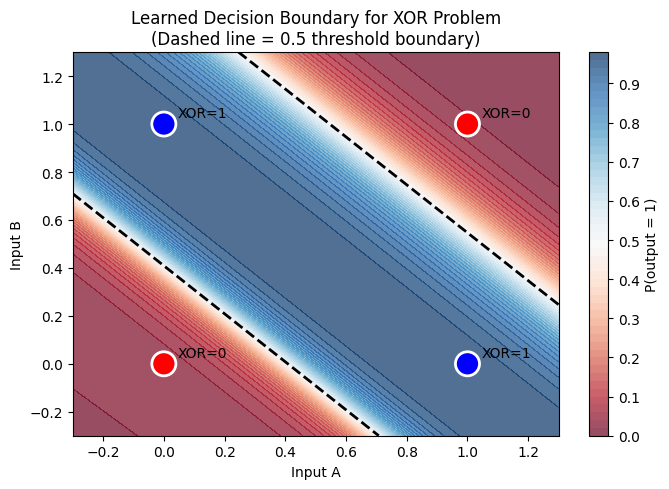

In [63]:
# Create a mesh grid to visualize the learned decision boundary
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 300), np.linspace(-0.3, 1.3, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = nn.forward(grid).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.7)
plt.colorbar(label='P(output = 1)')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')

colors = ['red' if label == 0 else 'blue' for label in y.flatten()]
plt.scatter(X[:, 0], X[:, 1], c=colors, s=300, edgecolors='white', zorder=5, linewidths=2)

# Annotate points
for i, (xi, yi, li) in enumerate(zip(X[:, 0], X[:, 1], y.flatten())):
    plt.annotate(f"XOR={li}", (xi, yi), textcoords="offset points", xytext=(10, 5), fontsize=10)

plt.title("Learned Decision Boundary for XOR Problem\n(Dashed line = 0.5 threshold boundary)")
plt.xlabel("Input A")
plt.ylabel("Input B")
plt.tight_layout()
plt.show()

## 💡 Step 9: Why a Single Perceptron Fails at XOR

Let us demonstrate visually why XOR requires a hidden layer.

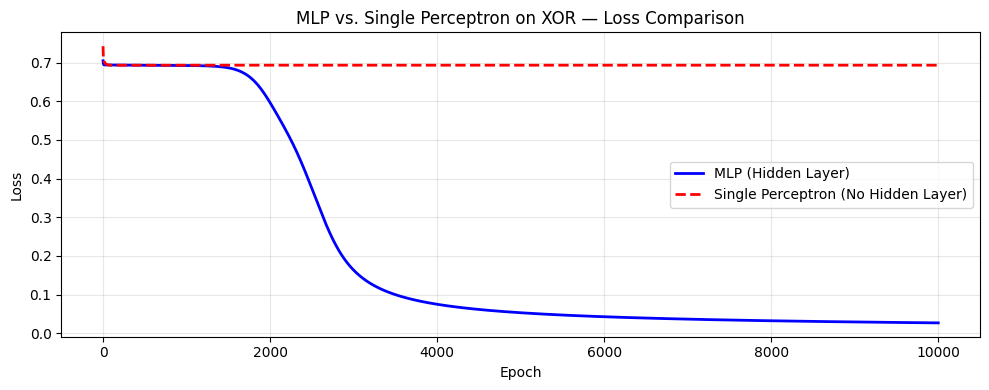

Single Perceptron Accuracy: 50.0%  (cannot solve XOR!)
MLP Accuracy:               100.0%  (solves XOR!)


In [64]:
# Attempt to solve XOR with a single neuron (perceptron) — this will fail!
class SinglePerceptron:
    """A single-layer perceptron — no hidden layers."""
    def __init__(self, lr=0.5):
        self.W = np.random.randn(2, 1) * 0.5
        self.b = np.zeros((1, 1))
        self.lr = lr
        self.loss_history = []

    def forward(self, X):
        return sigmoid(np.dot(X, self.W) + self.b)

    def train(self, X, y, epochs=10000):
        for _ in range(epochs):
            out = self.forward(X)
            loss = -np.mean(y * np.log(out + 1e-9) + (1 - y) * np.log(1 - out + 1e-9))
            self.loss_history.append(loss)
            dZ = out - y
            self.W -= self.lr * np.dot(X.T, dZ) / len(X)
            self.b -= self.lr * np.mean(dZ)

# Train single perceptron
sp = SinglePerceptron(lr=0.5)
sp.train(X, y, epochs=10000)

# Compare losses
plt.figure(figsize=(10, 4))
plt.plot(nn.loss_history, label='MLP (Hidden Layer)', color='blue', linewidth=2)
plt.plot(sp.loss_history, label='Single Perceptron (No Hidden Layer)', color='red', linewidth=2, linestyle='--')
plt.title("MLP vs. Single Perceptron on XOR — Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

sp_preds = (sp.forward(X) >= 0.5).astype(int)
print(f"Single Perceptron Accuracy: {np.mean(sp_preds == y)*100:.1f}%  (cannot solve XOR!)")
print(f"MLP Accuracy:               {np.mean(nn.predict(X) == y)*100:.1f}%  (solves XOR!)")

---

## 📝 Summary

| Concept | Key Insight |
|--------|-------------|
| **Forward Propagation** | Data flows input → hidden → output; each layer applies linear transform + activation |
| **Backpropagation** | Gradients flow output → hidden → input using the Chain Rule |
| **Gradient Descent** | Weights updated as: `W = W - lr * dL/dW` |
| **XOR Problem** | Requires at least 1 hidden layer (non-linear decision boundary) |
| **Sigmoid Derivative** | Used in backprop; vanishes at extremes → Vanishing Gradient issue |

---

## ❓ Viva / Self-Check Questions

1. **What is the Chain Rule in calculus and how is it used in Backpropagation?**

2. **Why can't a single perceptron (no hidden layers) solve the XOR problem?** Draw a diagram to support your answer.

3. **What happens if all weights are initialized to zero?** Why is random initialization important?

4. **What does the learning rate control?** What happens if it is too high or too low?

5. **The sigmoid derivative approaches 0 at large positive or negative values. What problem does this cause during training?** What is this phenomenon called?

6. **Modify the code to use a 3-layer MLP (2 hidden layers) for XOR. Does it still converge? Does it converge faster or slower?**

7. **What is Binary Cross-Entropy Loss? Why is it preferred over Mean Squared Error for classification tasks?**

8. **In the `backward` method, why do we divide gradients by `m` (the batch size)?**